In [1]:
!pip install -U gdown


In [2]:
!gdown 1-R50Wy0aSQuIwwfYzQluD9zLDwxO7zUQ


Downloading...
From (original): https://drive.google.com/uc?id=1-R50Wy0aSQuIwwfYzQluD9zLDwxO7zUQ
From (redirected): https://drive.google.com/uc?id=1-R50Wy0aSQuIwwfYzQluD9zLDwxO7zUQ&confirm=t&uuid=791c3fa9-8f9a-498d-9efa-8261bd85b5d0
To: /content/TrashNeXt Dataset.zip
100% 3.19G/3.19G [00:46<00:00, 68.8MB/s]


In [3]:
!unzip "TrashNeXt Dataset.zip"



Streaming output truncated to the last 5000 lines.
  inflating: TrashNeXt Dataset/Train/medical/medical 1322.jpg  
  inflating: __MACOSX/TrashNeXt Dataset/Train/medical/._medical 1322.jpg  
  inflating: TrashNeXt Dataset/Train/medical/medical 1444.jpg  
  inflating: __MACOSX/TrashNeXt Dataset/Train/medical/._medical 1444.jpg  
  inflating: TrashNeXt Dataset/Train/medical/medical 746.jpg  
  inflating: __MACOSX/TrashNeXt Dataset/Train/medical/._medical 746.jpg  
  inflating: TrashNeXt Dataset/Train/medical/medical 1875.jpg  
  inflating: __MACOSX/TrashNeXt Dataset/Train/medical/._medical 1875.jpg  
  inflating: TrashNeXt Dataset/Train/medical/medical 1861.jpg  
  inflating: __MACOSX/TrashNeXt Dataset/Train/medical/._medical 1861.jpg  
  inflating: TrashNeXt Dataset/Train/medical/medical 593.jpg  
  inflating: __MACOSX/TrashNeXt Dataset/Train/medical/._medical 593.jpg  
  inflating: TrashNeXt Dataset/Train/medical/medical 1691.jpg  
  inflating: __MACOSX/TrashNeXt Dataset/Train/medical/.

In [4]:
!unzip "Test and Valid Dataset.zip"
!unzip "Train Dataset.zip"


unzip:  cannot find or open Test and Valid Dataset.zip, Test and Valid Dataset.zip.zip or Test and Valid Dataset.zip.ZIP.
unzip:  cannot find or open Train Dataset.zip, Train Dataset.zip.zip or Train Dataset.zip.ZIP.


In [5]:
!ls


 __MACOSX   sample_data  'TrashNeXt Dataset'  'TrashNeXt Dataset.zip'


In [6]:
!ls 'TrashNeXt Dataset'

Test  Train  Valid


In [7]:
ArithmeticErrordata_dir = "TrashNeXt Dataset/Train"

In [8]:
!mv 'TrashNeXt Dataset/Train' .
!mv 'TrashNeXt Dataset/Test' .
!mv 'TrashNeXt Dataset/Valid' .

In [9]:
!ls Train*
!ls Test*



cardboard  e-waste  foam_rubber  glass	medical  metal	organic  paper	plastic
cardboard  e-waste  foam_rubber  glass	medical  metal	organic  paper	plastic


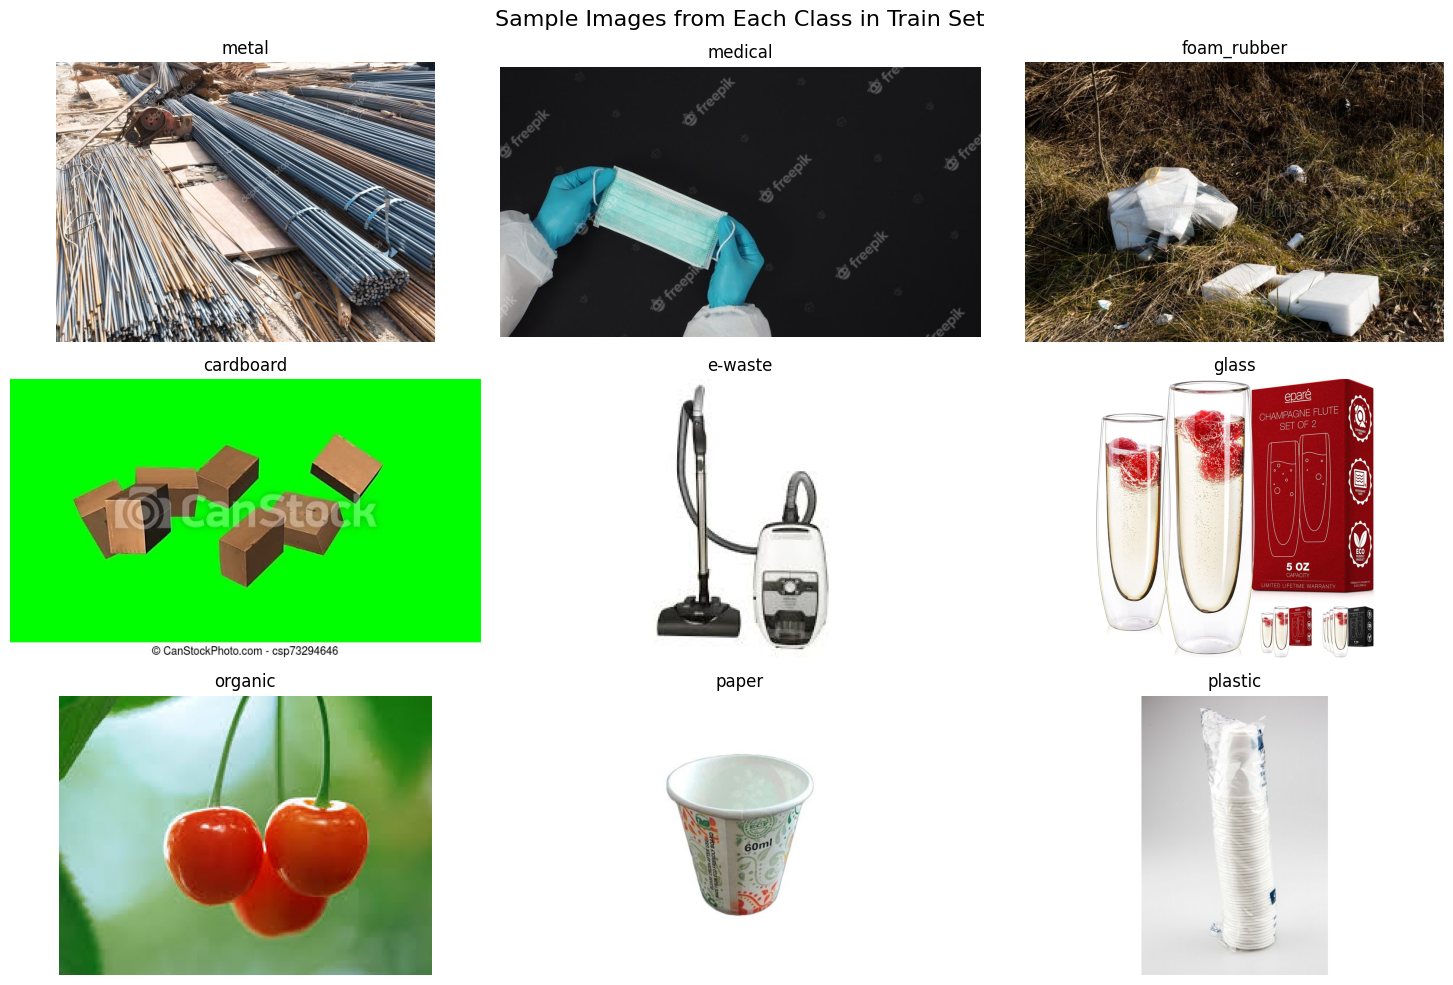

In [10]:
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

data_dir = "Train"
classes = [d for d in os.listdir(data_dir) if os.path.isdir(os.path.join(data_dir, d))]

plt.figure(figsize=(15, 10))
for i, class_name in enumerate(classes[:9]):
    img_path = os.path.join(data_dir, class_name)
    img_file = os.path.join(img_path, os.listdir(img_path)[0])
    img = mpimg.imread(img_file)
    plt.subplot(3, 3, i + 1)
    plt.imshow(img)
    plt.title(class_name)
    plt.axis('off')
plt.suptitle("Sample Images from Each Class in Train Set", fontsize=16)
plt.tight_layout()
plt.show()



In [11]:
train_dir = "Train"
class_counts = {
    class_name: len(os.listdir(os.path.join(train_dir, class_name)))
    for class_name in os.listdir(train_dir)
    if os.path.isdir(os.path.join(train_dir, class_name))
}


In [12]:
import os

def count_images_in_classes(base_dir):
    classes = os.listdir(base_dir)
    class_counts = {}
    for cls in classes:
        cls_path = os.path.join(base_dir, cls)
        if os.path.isdir(cls_path):
            # Count files in this class folder (assuming all are images)
            count = len([f for f in os.listdir(cls_path) if os.path.isfile(os.path.join(cls_path, f))])
            class_counts[cls] = count
    return class_counts

train_counts = count_images_in_classes("Train")
test_counts = count_images_in_classes("Test")
valid_counts = count_images_in_classes("Valid")

print("Train set image counts:", train_counts)
print("Test set image counts:", test_counts)
print("Valid set image counts:", valid_counts)


Train set image counts: {'metal': 2065, 'medical': 1565, 'foam_rubber': 2289, 'cardboard': 1886, 'e-waste': 2404, 'glass': 2009, 'organic': 2391, 'paper': 2155, 'plastic': 2135}
Test set image counts: {'metal': 258, 'medical': 196, 'foam_rubber': 287, 'cardboard': 235, 'e-waste': 301, 'glass': 252, 'organic': 299, 'paper': 270, 'plastic': 267}
Valid set image counts: {'metal': 258, 'medical': 196, 'foam_rubber': 287, 'cardboard': 236, 'e-waste': 301, 'glass': 251, 'organic': 299, 'paper': 269, 'plastic': 267}


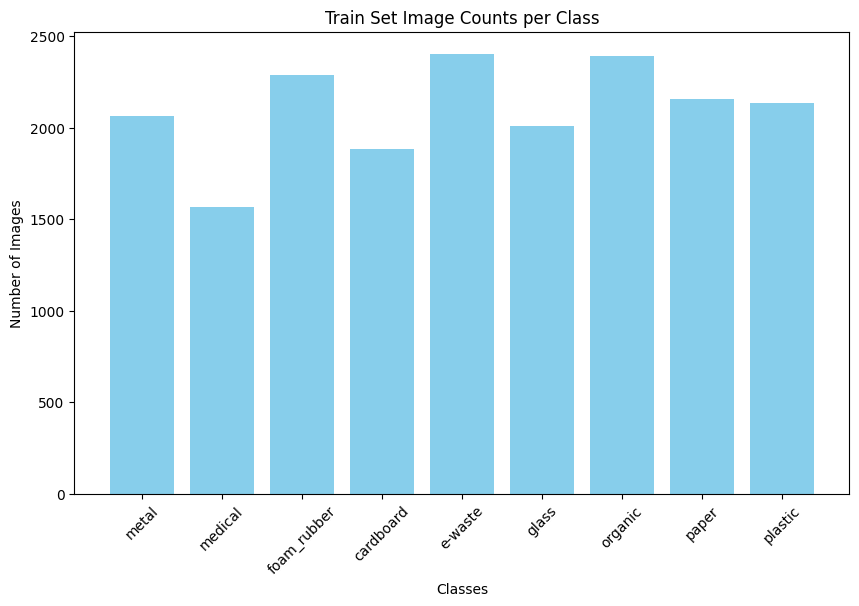

In [13]:
import matplotlib.pyplot as plt

def plot_bar_chart(class_counts, title):
    classes = list(class_counts.keys())
    counts = list(class_counts.values())

    plt.figure(figsize=(10, 6))
    plt.bar(classes, counts, color='skyblue')
    plt.xlabel('Classes')
    plt.ylabel('Number of Images')
    plt.title(title)
    plt.xticks(rotation=45)
    plt.show()

# Example usage:
plot_bar_chart(train_counts, "Train Set Image Counts per Class")


In [14]:
import pandas as pd

def create_summary_table(class_counts):
    total = sum(class_counts.values())
    data = {
        "Class": list(class_counts.keys()),
        "Image Count": list(class_counts.values()),
        "Percentage": [f"{(count/total)*100:.2f}%" for count in class_counts.values()]
    }
    df = pd.DataFrame(data)
    return df

# Example:
train_summary = create_summary_table(train_counts)
print(train_summary)


         Class  Image Count Percentage
0        metal         2065     10.93%
1      medical         1565      8.28%
2  foam_rubber         2289     12.11%
3    cardboard         1886      9.98%
4      e-waste         2404     12.72%
5        glass         2009     10.63%
6      organic         2391     12.65%
7        paper         2155     11.40%
8      plastic         2135     11.30%


DONE WITH UNDERSTANDING DATASETS

In [15]:
import os
from PIL import Image

def deeply_clean_dataset_dir(directory):
    print(f"Deep cleaning dataset directory: {directory}")
    count = 0
    for root, _, files in os.walk(directory):
        for file in files:
            filepath = os.path.join(root, file)
            try:
                with Image.open(filepath) as img:
                    img.convert("RGB")  # Try to load & convert the image
            except Exception:
                print(f"Removing corrupted or unsupported file: {filepath}")
                os.remove(filepath)
                count += 1
    print(f"Deep cleaning done. Removed {count} files.\n")

deeply_clean_dataset_dir("Train")
deeply_clean_dataset_dir("Valid")
deeply_clean_dataset_dir("Test")


Deep cleaning dataset directory: Train
Removing corrupted or unsupported file: Train/.DS_Store


/usr/local/lib/python3.11/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Removing corrupted or unsupported file: Train/foam_rubber/desktop.ini
Deep cleaning done. Removed 2 files.

Deep cleaning dataset directory: Valid
Removing corrupted or unsupported file: Valid/.DS_Store
Removing corrupted or unsupported file: Valid/foam_rubber/desktop.ini
Removing corrupted or unsupported file: Valid/foam_rubber/Tire (145).jpg
Deep cleaning done. Removed 3 files.

Deep cleaning dataset directory: Test
Removing corrupted or unsupported file: Test/.DS_Store
Removing corrupted or unsupported file: Test/foam_rubber/desktop.ini
Deep cleaning done. Removed 2 files.



In [16]:

import os

def remove_non_image_files(directory, valid_extensions={'.jpg', '.jpeg', '.png', '.bmp', '.gif'}):
    print(f"Checking for non-image files in: {directory}")
    count = 0
    for root, _, files in os.walk(directory):
        for file in files:
            ext = os.path.splitext(file)[1].lower()
            if ext not in valid_extensions:
                filepath = os.path.join(root, file)
                print(f"Removing non-image file: {filepath}")
                os.remove(filepath)
                count += 1
    print(f"Removed {count} non-image files from {directory}.\n")

remove_non_image_files("Train")
remove_non_image_files("Valid")
remove_non_image_files("Test")

Checking for non-image files in: Train
Removed 0 non-image files from Train.

Checking for non-image files in: Valid
Removed 0 non-image files from Valid.

Checking for non-image files in: Test
Removed 0 non-image files from Test.



In [17]:
import tensorflow as tf

def remove_tf_unreadable_images(directory):
    print(f"Checking TensorFlow readability in: {directory}")
    count = 0
    for root, _, files in os.walk(directory):
        for file in files:
            filepath = os.path.join(root, file)
            try:
                # Try to decode the image using TensorFlow
                img_raw = tf.io.read_file(filepath)
                _ = tf.image.decode_image(img_raw)
            except Exception:
                print(f"Removing unreadable image for TensorFlow: {filepath}")
                os.remove(filepath)
                count += 1
    print(f"Removed {count} TensorFlow-unreadable images from {directory}.\n")

remove_tf_unreadable_images("Train")
remove_tf_unreadable_images("Valid")
remove_tf_unreadable_images("Test")

Checking TensorFlow readability in: Train
Removing unreadable image for TensorFlow: Train/metal/metal 1625.jpg
Removing unreadable image for TensorFlow: Train/metal/metal 1209.jpg
Removing unreadable image for TensorFlow: Train/metal/metal 102.jpg
Removing unreadable image for TensorFlow: Train/metal/metal 1521.jpg
Removing unreadable image for TensorFlow: Train/medical/medical 727.jpg
Removing unreadable image for TensorFlow: Train/medical/medical 1111.jpg
Removing unreadable image for TensorFlow: Train/medical/medical 1004.jpg
Removing unreadable image for TensorFlow: Train/medical/medical 541.jpg
Removing unreadable image for TensorFlow: Train/medical/medical 1734.jpg
Removing unreadable image for TensorFlow: Train/medical/medical 1342.jpg
Removing unreadable image for TensorFlow: Train/medical/medical 1299.jpg
Removing unreadable image for TensorFlow: Train/medical/medical 1258.jpg
Removing unreadable image for TensorFlow: Train/medical/medical 1116.jpg
Removing unreadable image fo

In [ ]:
# EfficientNetV2-M + LeViT Feature Extraction + XGBoost / CatBoost / LightGBM Classifier

# Step 1: Install dependencies
!pip install -q timm xgboost catboost lightgbm torchvision

# Step 2: Imports
import timm
import torch
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier

# Step 3: Data Loading (change path to your dataset)
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

dataset = ImageFolder("Train", transform=transform)
dataloader = DataLoader(dataset, batch_size=32, shuffle=False)
class_names = dataset.classes
print("Classes:", class_names)

# Step 4: Load EfficientNetV2-M and LeViT (from timm)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

effnet = timm.create_model("tf_efficientnetv2_m", pretrained=True, num_classes=0).to(device).eval()
levit = timm.create_model("levit_128", pretrained=True, num_classes=0).to(device).eval()

# Step 5: Feature Extraction
all_features = []
all_labels = []

with torch.no_grad():
    for images, labels in dataloader:
        images = images.to(device)

        eff_feat = effnet(images)     # (batch, 1280)
        levit_feat = levit(images)    # (batch, 128)

        combined = torch.cat((eff_feat, levit_feat), dim=1)  # (batch, 1408)
        all_features.append(combined.cpu().numpy())
        all_labels.append(labels.numpy())

X = np.concatenate(all_features)
y = np.concatenate(all_labels)
print("Feature shape:", X.shape)

# Step 6: Split Train/Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 7: Train Classifiers
# --- XGBoost ---
xgb_model = XGBClassifier(n_estimators=100)
xgb_model.fit(X_train, y_train)
xgb_preds = xgb_model.predict(X_test)
print("XGBoost Accuracy:", accuracy_score(y_test, xgb_preds))

# --- LightGBM ---
lgb_model = LGBMClassifier(n_estimators=100)
lgb_model.fit(X_train, y_train)
lgb_preds = lgb_model.predict(X_test)
print("LightGBM Accuracy:", accuracy_score(y_test, lgb_preds))

# --- CatBoost ---
cat_model = CatBoostClassifier(verbose=0)
cat_model.fit(X_train, y_train)
cat_preds = cat_model.predict(X_test)
print("CatBoost Accuracy:", accuracy_score(y_test, cat_preds))


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.7/188.7 MB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 68.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 35.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 50.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 14.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 97.5 MB/s eta 0:00:00
Classes: ['cardboard', 'e-waste', 'foam_rubbe

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/218M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/37.1M [00:00<?, ?B/s]